# Single Particle Tracking simulator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
import random
import stackview
import cv2
from skimage.feature import peak_local_max
from scipy.optimize import curve_fit

In [2]:
from helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
%reload_ext autoreload
%autoreload 2
import helpers, helpersGeneration, helpersTracking, helpersStatistics

## 1. Particles generation

Goal: create a generator of N particles at random positions in (0, 128) (not too close to edges) with diffusion coefficient in (0,4)

In [3]:
N =10
particles = generate_particles_OOP(N) # a list of Particle objects

### 1.1 Image generation

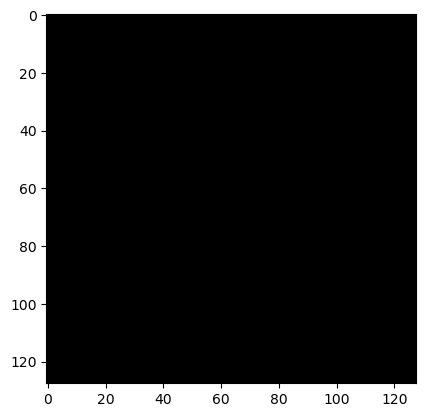

In [4]:
img = uniform_bg(128, value=100)
show_img(img)

### 1.2 Particles placement and Gaussian blur

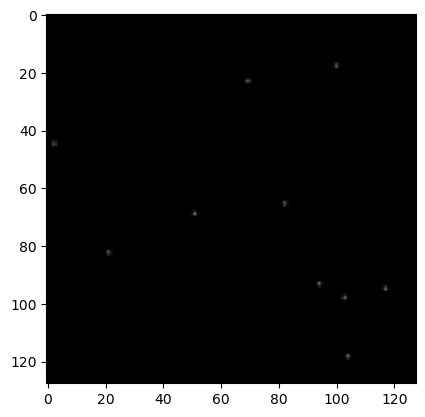

In [5]:
img = place_particles_OOP(img, particles, c = 30000, sigma = 0.5)
show_img(img)

In [6]:
# check min and max of image
check_min_max(img)

min: 100
max: 28097


### 1.3 Noise addition

Gaussian and Poisson noise

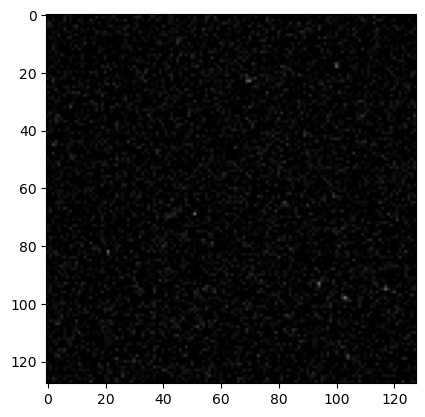

min: 0.0
max: 30820.036892386626


In [7]:
noisy_img = img.copy()
noisy_img = add_gaussian_noise(noisy_img, mean=100, std=4000)
show_img(noisy_img)
check_min_max(noisy_img)

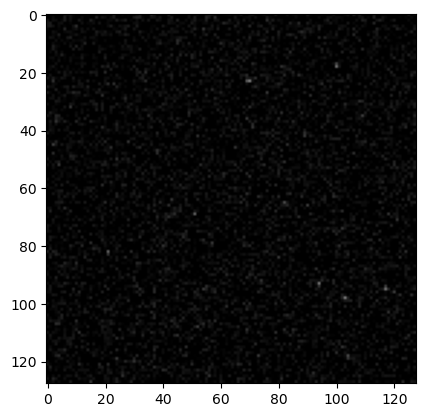

min: 0.0
max: 31390.96250131139


In [8]:
noisy_img = add_poisson_noise(noisy_img)
show_img(noisy_img)
check_min_max(noisy_img)

## 2. Frames generation

Update following normal diffusion (Brownian motion)

In [ ]:
F = 20
# trajectories_GT represent the TRUE trajectories of each particle
frames, trajectories_GT, D_GT = generate_frames_OOP(F, N, amp = 50000, noise_gaussian=True, noise_poisson=True) 

Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
Frame 10
Frame 11
Frame 12
Frame 13
Frame 14
Frame 15
Frame 16
Frame 17
Frame 18
Frame 19
Frame 20


Visualization: stackview

In [10]:
viewer = view_frames(frames)
viewer

## 3. MSD Extraction

### 3.0 $ D_{GT} $

In [ ]:
 print('D_GT =', D_GT)

D_GT = [0, 0, 2, 3, 4, 2, 1, 3, 3, 0]


### 3.1 $ D_{trajectory} $

In [12]:
msd_trajectory = msd_trajectories(trajectories_GT)

In [13]:
D_trajectory = estimateDfromTrajectories(trajectories_GT)
print(f"D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in D_trajectory)}]")

D_trajectory: 
[1.188, 4.191, -0.000, -0.000, 1.294, 0.503, 1.868, 1.391, 2.896, 2.289]


In [14]:
MAE_trajectory = np.abs(np.array(D_trajectory) - np.array(D_GT))
print(f"MAE for D_trajectory: \n[{', '.join(f'{float(d):.3f}' for d in MAE_trajectory)}]")

MAE for D_trajectory: 
[1.188, 4.191, 2.000, 3.000, 2.706, 1.497, 0.868, 1.609, 0.104, 2.289]


### 3.2 $ D_{detection} $

Detection followed by Local Nearest Neighbor tracking

In [15]:
detected_peaks = detect_peaks(frames)

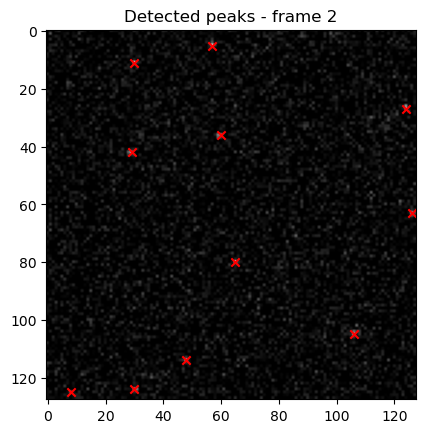

In [16]:
visualize_peaks(detected_peaks[0], frames[0], 1)

In [17]:
trajectories_detection = NN_tracking(detected_peaks, max_distance=5)

print("Number of trajectories:", len(trajectories_detection))
print("Sizes of trajectories:", [len(traj.get_positions()) for traj in trajectories_detection])

Number of trajectories: 11
Sizes of trajectories: [20, 20, 20, 3, 20, 1, 20, 1, 20, 20, 1]


Assigning each detected trajectory to a GT trajectory:

In [18]:
cog_detection = [cog(traj) for traj in trajectories_detection]

In [19]:
# calculate cog for GT trajectories
cog_GT = [cog(traj) for traj in trajectories_GT]

In [20]:
# print IDs before assignment
print("Detected trajectories IDs before assignment:")
for i, traj in enumerate(trajectories_detection):
    print(f"Detection Trajectory {i}: ID = {traj.id}")

Detected trajectories IDs before assignment:
Detection Trajectory 0: ID = 0
Detection Trajectory 1: ID = 1
Detection Trajectory 2: ID = 2
Detection Trajectory 3: ID = 3
Detection Trajectory 4: ID = 4
Detection Trajectory 5: ID = 5
Detection Trajectory 6: ID = 6
Detection Trajectory 7: ID = 7
Detection Trajectory 8: ID = 8
Detection Trajectory 9: ID = 9
Detection Trajectory 10: ID = 10


In [21]:
label_trajectories_from_GT(trajectories_detection, trajectories_GT, max_distance=10)

Assigned (76.2, 61.15) to GT (75.8940537189977, 60.5047553020677) -> id 2
Assigned (21.1, 33.7) to GT (21.577856823321095, 34.15168660336345) -> id 9
Assigned (114.0, 48.0) to GT (113.85117107188243, 47.85827361276584) -> id 4
Assigned (3.0, 57.666666666666664) to GT (0.40859355573718315, 51.73801921795426) -> id 10
Assigned (106.55, 109.15) to GT (106.6272705000907, 109.41626087639331) -> id 6
Assigned (63.0, 126.0) to GT (58.27192520635121, 120.2483696097953) -> id 7
Assigned (46.25, 22.0) to GT (46.421535540691686, 21.384774109386477) -> id 5
Assigned (124.0, 30.0) to GT (125.24801959375354, 32.10584561156664) -> id 1
Assigned (23.75, 116.6) to GT (23.321249819746686, 115.93260069395266) -> id 8
Assigned (36.0, 59.2) to GT (36.35547297762789, 59.444400517031795) -> id 3
No GT cog within max distance for (125.0, 8.0) -> id None


In [23]:
# print IDs after assignment
print("Detected trajectories IDs after assignment:")
for i, traj in enumerate(trajectories_detection):
    print(f"Detection Trajectory {i}: ID = {traj.id}")

Detected trajectories IDs after assignment:
Detection Trajectory 0: ID = 2
Detection Trajectory 1: ID = 9
Detection Trajectory 2: ID = 4
Detection Trajectory 3: ID = 10
Detection Trajectory 4: ID = 6
Detection Trajectory 5: ID = 7
Detection Trajectory 6: ID = 5
Detection Trajectory 7: ID = 1
Detection Trajectory 8: ID = 8
Detection Trajectory 9: ID = 3
Detection Trajectory 10: ID = None


In [78]:
############# TO DO: Assignment by Hungarian algorithm #############

In [24]:
print("Sizes of trajectories per GT ID:\n", {traj.id: len(traj.get_positions()) for traj in trajectories_detection})

Sizes of trajectories per GT ID:
 {2: 20, 9: 20, 4: 20, 10: 3, 6: 20, 7: 1, 5: 20, 1: 1, 8: 20, 3: 20, None: 1}


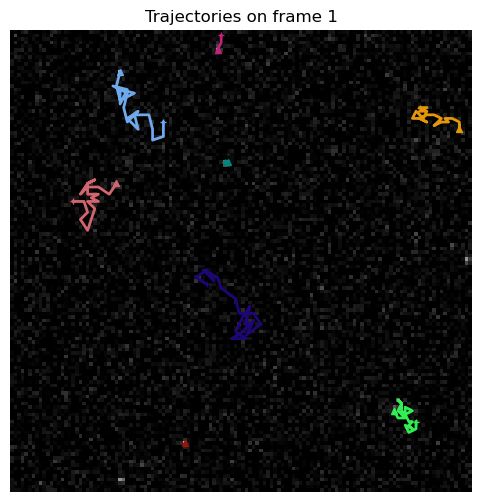

In [25]:
show_trajectories(frames, trajectories_detection, frame_id=0)

In [26]:
msd_detection = msd_trajectories(trajectories_detection)

In [27]:
print(len(msd_detection))
print(len(msd_detection[0]))
print(trajectories_detection[0].msd)

10
20
[  0.          16.47368421  29.88888889  47.70588235  77.8125
 101.2        132.92857143 166.53846154 195.33333333 225.27272727
 241.1        252.22222222 260.5        276.71428571 292.16666667
 290.         242.25       262.33333333 260.         221.        ]


In [28]:
D_detection = estimateDfromTrajectories(trajectories_detection)
print(f"D_detection: \n[{', '.join(f'{float(d):.3f}' for d in D_detection)}]")

D_detection: 
[4.469, 3.987, -0.000, 1.925, 0.611, 0.000, 1.533, 0.000, 1.562, 0.008, 0.000]


In [29]:
# calculate MAE for D_detection based on D_GT indices
MAE_detection = []
for id in range(N):
    MAE_detection.append(np.abs(D_detection[id] - D_GT[id]))
print(f"MAE for D_detection: \n[{', '.join(f'{float(d):.3f}' for d in MAE_detection)}]")

MAE for D_detection: 
[4.469, 3.987, 2.000, 1.075, 3.389, 2.000, 0.533, 3.000, 1.438, 0.008]


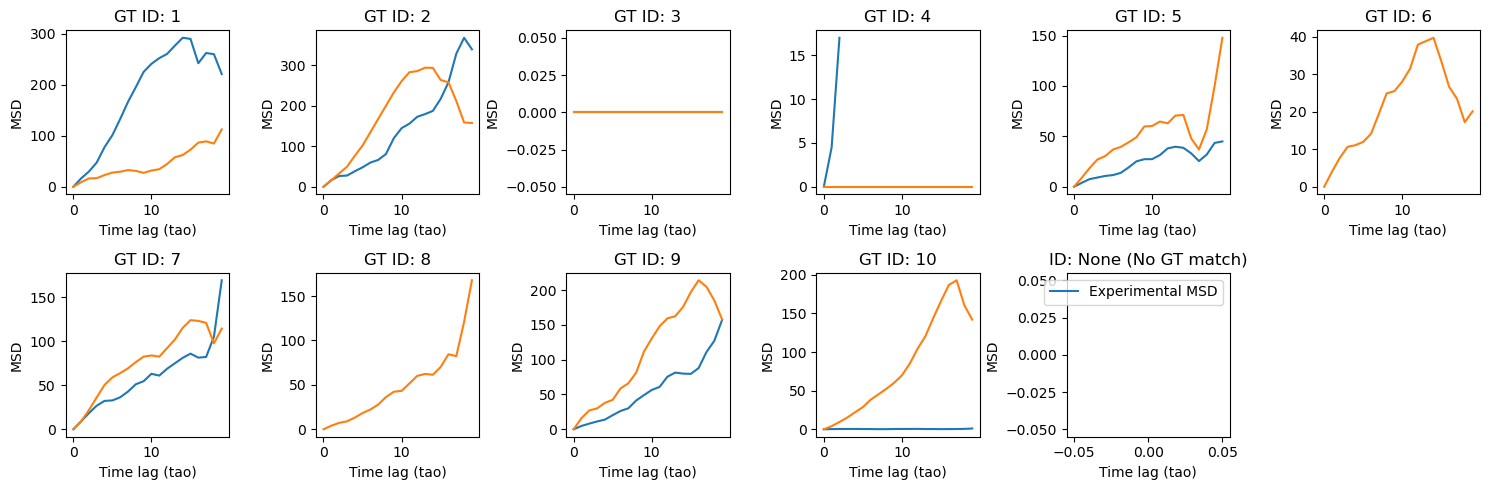

In [30]:
plot_msd_vs_trajectory_msd(trajectories_detection, trajectories_GT)

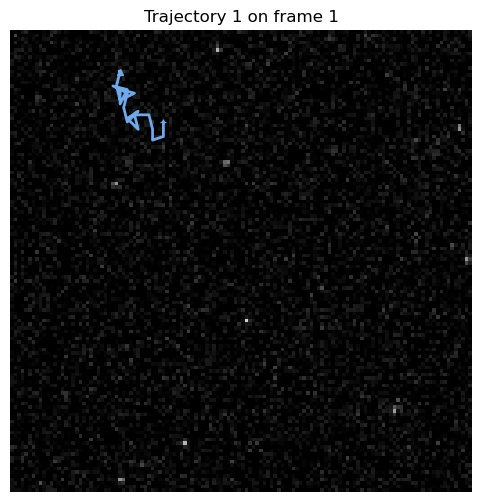

In [31]:
show_trajectory(frames, trajectories_detection, traj_id=1)

### 3.3 D_localization

By Gaussian fitting

In [32]:
def gaussian_2d(xy, amp, x0, y0, sigma_x, sigma_y):
            x, y = xy
            return amp * np.exp(-(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2))) #remettre sigma ds amp

In [33]:
print(len(detected_peaks))
print(detected_peaks[0])

20
[[ 80  65]
 [ 11  30]
 [114  48]
 [  5  57]
 [105 106]
 [ 63 126]
 [ 42  29]
 [124  30]
 [ 27 124]
 [ 36  60]
 [125   8]]


In [34]:
# fit a 9x9 square around detected peaks, use center pixel as initial guess, extract the center coordinates (floats) by gaussian fitting
# return localized peaks in the same format as detected peaks, but with subpixel coordinates (floats) instead of integers
localized_peaks = []

for i in range(len(frames)):
    localized_peaks_frame = []
    for peak in detected_peaks[i]:

        x, y = peak

        patch = frames[i][x-4:x+5, y-4:y+5] # 9x9 patch
        if patch.shape != (9, 9):
            continue

        x_data = np.arange(patch.shape[1])
        y_data = np.arange(patch.shape[0])
        x_data, y_data = np.meshgrid(x_data, y_data)

        # local coordinates inside the patch
        initial_guess = (patch.max(), 4.0, 4.0, 1.0, 1.0) # center of patch as initial guess

       
        popt, _ = curve_fit(
            gaussian_2d,
            (x_data.ravel(), y_data.ravel()),
            patch.ravel(),
            p0=initial_guess
        )

        amp_fit, x0_fit, y0_fit, sigma_x_fit, sigma_y_fit = popt

        # convert back to image coordinates
        x0_img = (x - 4) + x0_fit # x y swap? to check
        y0_img = (y - 4) + y0_fit

        print(
            f"Fitted center for peak at ({x}, {y}): "
            f"({x0_img:.2f}, {y0_img:.2f})"
        )
        localized_peaks_frame.append((y0_img, x0_img)) # order (y, x) to be consistent with image coordinates (row, column)


    localized_peaks.append(localized_peaks_frame)


Fitted center for peak at (80, 65): (80.11, 64.99)
Fitted center for peak at (11, 30): (11.14, 29.97)
Fitted center for peak at (114, 48): (113.90, 47.97)
Fitted center for peak at (5, 57): (5.07, 56.84)
Fitted center for peak at (105, 106): (105.00, 105.80)
Fitted center for peak at (42, 29): (41.72, 29.14)
Fitted center for peak at (36, 60): (35.47, 60.35)
Fitted center for peak at (114, 48): (113.76, 47.93)
Fitted center for peak at (15, 29): (14.97, 28.94)
Fitted center for peak at (45, 27): (44.84, 26.59)
Fitted center for peak at (76, 66): (76.35, 66.15)
Fitted center for peak at (36, 59): (36.41, 59.22)
Fitted center for peak at (107, 107): (106.72, 106.56)
Fitted center for peak at (102, 24): (103.14, 24.02)
Fitted center for peak at (114, 48): (113.83, 47.90)
Fitted center for peak at (79, 64): (78.80, 64.31)
Fitted center for peak at (19, 30): (18.77, 29.68)
Fitted center for peak at (43, 24): (43.35, 23.95)
Fitted center for peak at (24, 122): (23.59, 122.14)
Fitted center f

In [35]:
trajectories_localization = NN_tracking(localized_peaks, max_distance=5)

In [36]:
print("Number of trajectories (localization):", len(trajectories_localization))

Number of trajectories (localization): 7


In [37]:
cog_localization = [cog(traj) for traj in trajectories_localization]

In [44]:
label_trajectories_from_GT(trajectories_localization, trajectories_GT, max_distance=20)

No GT cog within max distance for (64.26790222817436, 81.78069677919686) -> id None
Assigned (30.546171219587137, 16.262540755361016) to GT (46.421535540691686, 21.384774109386477) -> id 5
Assigned (47.878597818225, 113.865803199124) to GT (58.27192520635121, 120.2483696097953) -> id 7
No GT cog within max distance for (56.83628787829532, 5.065631520061622) -> id None
Assigned (109.15766542033282, 106.52330358484355) to GT (106.6272705000907, 109.41626087639331) -> id 6
Assigned (22.03967010533644, 46.33059491092423) to GT (21.577856823321095, 34.15168660336345) -> id 9
No GT cog within max distance for (59.51250529514347, 36.24821118633865) -> id None


In [45]:
msd_localization = msd_trajectories(trajectories_localization)

In [46]:
print(len(msd_localization))

4


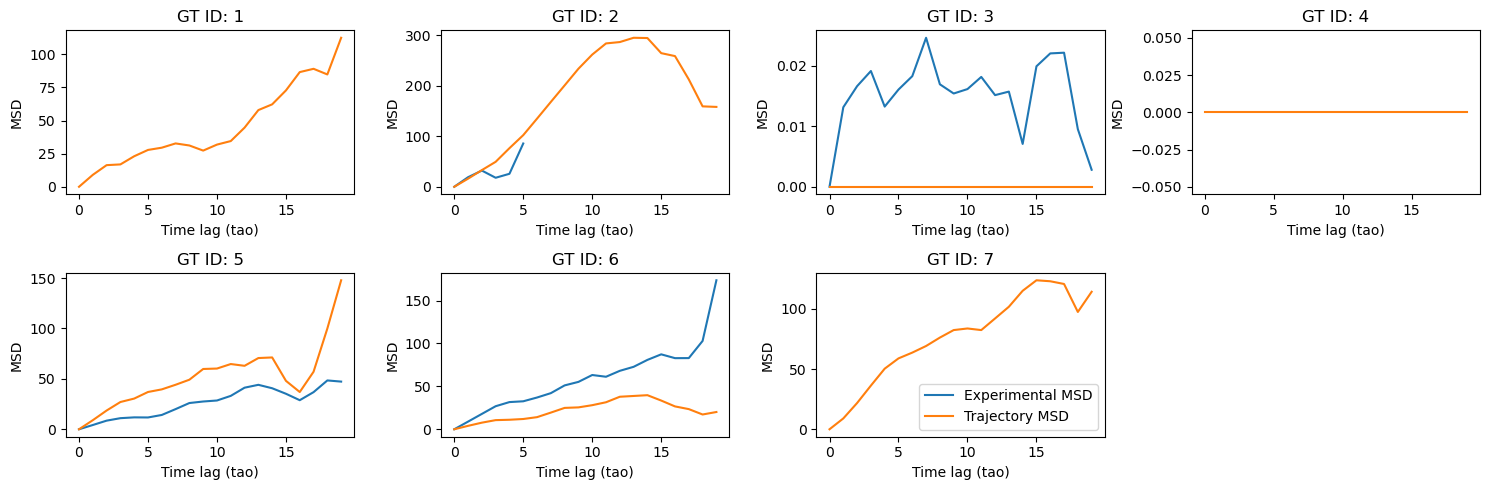

In [47]:
plot_msd_vs_trajectory_msd(trajectories_localization, trajectories_GT)

In [49]:
D_localization = estimateDfromTrajectories(trajectories_localization)
print(f"D_localization: \n[{', '.join(f'{float(d):.3f}' for d in D_localization)}]")

D_localization: 
[0.000, 3.031, 0.000, 0.000, 0.660, 1.542, 0.000]


In [50]:
print(len(D_localization))

7


In [51]:
MAE_localization = []
for id in range(len(D_localization)):
    if np.isnan(D_localization[id]):
        continue
    mae = abs(D_localization[id] - D_GT[id])
    MAE_localization.append(mae)
print(f"MAE for D_localization: \n[{', '.join(f'{float(d):.3f}' for d in MAE_localization)}]")

MAE for D_localization: 
[0.000, 3.031, 2.000, 3.000, 3.340, 0.458, 1.000]


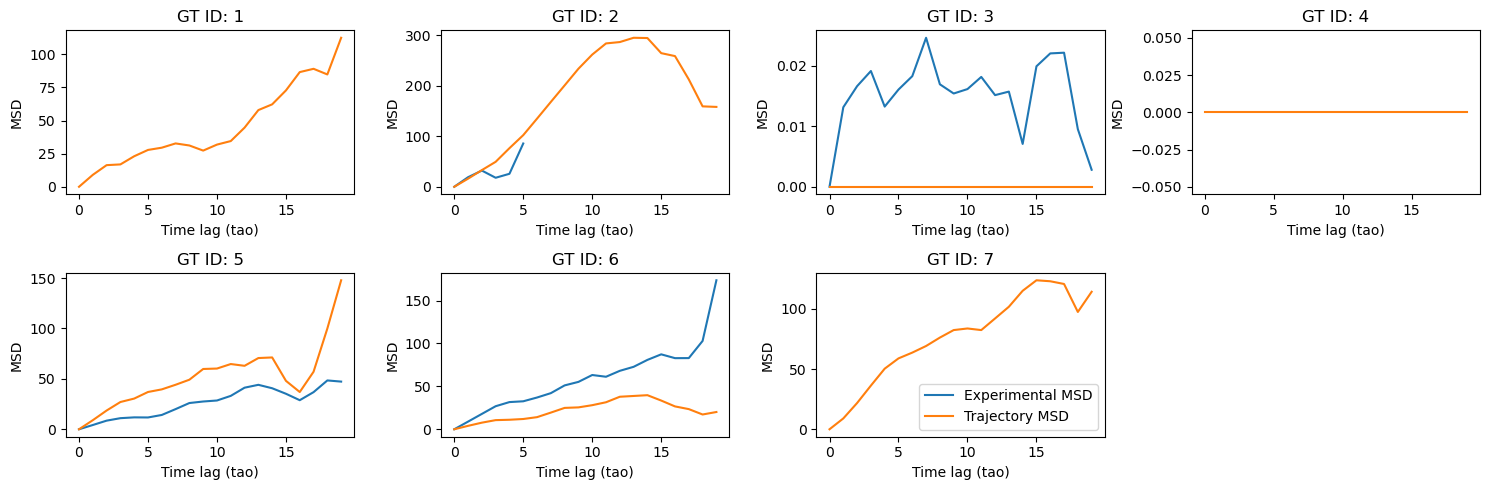

In [53]:
plot_msd_vs_trajectory_msd(trajectories_localization, trajectories_GT)